# Supplement — choosing the prior variance $\tau^2$ (analytic Gaussian CIPHER posterior)

Sweeps the prior variance $\tau^2$ in the analytic Gaussian posterior

$$y = \Sigma u + \varepsilon,\quad \varepsilon\sim\mathcal N(0,H),\quad u\sim\mathcal N(0,\tau^2 I),\qquad C_\tau = H + \tau^2\,\Sigma\Sigma^\top,$$

and shows how the marginal likelihood $\log p(\Delta x\mid\tau^2)$, its plateau, the
evidence slope, and the posterior fit ($R^2$, force size) vary with $\tau^2$ — the basis
for the $\tau^2$ choice.

This notebook has two sections that share the whitened-eigendecomposition sweep engine:

* **KRAS section** — pancreatic naive vs resistant (`pancreatic_naive_vs_resistant.h5ad`).
* **Melanoma section** — GSE233766 naive vs resistant (`GSE233766/Xtot_naive_resistant_melanoma_unbalanced.h5ad`).

Each section computes $\Sigma$, $H$, $\Delta x$ from cells (caching the `.npy` under
`OUTDIR`), then feeds them to the **shared** sweep engine
(`prepare_whitened_eigendecomposition` / `evaluate_tau2_grid` / `plot_tau_sweep`).
Helper engine lives in `notebooks/src/suppl_posterior.py` (notebook-only; not part of the
`cipher` package). The two dataset compute pipelines genuinely differ (shrinkage, `H` mode,
DE selection), so the melanoma pipeline is exposed under `*_mel` names.

In [1]:
import os, sys
# route tqdm progress bars to text (stderr -> log) instead of un-renderable ipywidgets
import importlib as _il
try:
    _std_tqdm = _il.import_module('tqdm.std').tqdm
    for _m in ('tqdm', 'tqdm.auto', 'tqdm.notebook', 'tqdm.autonotebook'):
        try: _il.import_module(_m).tqdm = _std_tqdm
        except Exception: pass
except Exception:
    pass
sys.path.insert(0, os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'suppl' else os.getcwd())

import numpy as np
import pandas as pd
from pathlib import Path

# shared engine + both dataset compute pipelines (helpers in notebooks/src; not part of cipher)
from src.suppl_posterior import *
import src.suppl_posterior as sp

DATA_DIR = os.environ["CIPHER_DATA_DIR"]          # set in the sbatch script; no fallback
SUPPL = os.path.join(DATA_DIR, "suppl")
OUTDIR = os.environ.get("SUPPL_OUT", "resources/repro/tau2")
os.makedirs(OUTDIR, exist_ok=True)
from src.logutil import route_logs  # verbose logs -> .log, plots stay in-cell
route_logs("tau2_selection")
print("data dir:", DATA_DIR)
print("suppl:   ", SUPPL)
print("outdir:  ", OUTDIR)

# ------------------------------------------------------------------
# Shared tau2 sweep engine settings (common to both datasets)
# ------------------------------------------------------------------
TAU2_GRID = np.logspace(-14, 4, 361)   # includes very tiny tau2 to test evidence saturation
INCLUDE_TAU2_ZERO = True               # exact tau2 -> 0 limiting model (C = H, mu = 0)

sp.SYMMETRIZE = True
sp.CHOLESKY_JITTER_REL = 1e-10
sp.CHOLESKY_MAX_TRIES = 10
sp.PLATEAU_DELTA_LOGML = 1.0
sp.COMPUTE_POSTERIOR_DIAGNOSTICS = True
sp.DPI = 300

[logs] verbose output -> ../../resources/repro/tau2/logs/tau2_selection.log
data dir: $CIPHER_DATA_DIR
suppl:    $SUPPL
outdir:   $SUPPL_OUT


In [2]:
def run_tau2_sweep(data, sec_dir):
    """Shared main flow: whitened sweep engine + figures + best-tau2 posterior save."""
    os.makedirs(sec_dir, exist_ok=True)
    sec_dir = Path(sec_dir)

    gene_names = data["gene_names"]
    y = np.asarray(data["y"], dtype=np.float64).reshape(-1)
    Sigma = np.asarray(data["Sigma"], dtype=np.float64)
    H = np.asarray(data["H"], dtype=np.float64)

    print("\n[input]")
    print(f"  Sigma shape: {Sigma.shape}")
    print(f"  H shape:     {H.shape}")
    print(f"  y shape:     {y.shape}")
    print(f"  y norm:      {np.linalg.norm(y):.6g}")

    prep = prepare_whitened_eigendecomposition(Sigma=Sigma, H=H, y=y)

    sweep_df = evaluate_tau2_grid(
        prep=prep,
        tau2_grid=TAU2_GRID,
        include_tau2_zero=INCLUDE_TAU2_ZERO,
    )

    table_path = sec_dir / "tau2_sweep_marginal_likelihood.tsv"
    sweep_df.to_csv(table_path, sep="\t", index=False)
    print(f"\n[saved] {table_path}")

    summary_info = plot_tau_sweep(sweep_df, sec_dir)

    best_tau2 = summary_info["best_tau2"]
    best_tau = summary_info["best_tau"]

    # Save best-tau2 posterior mu / yhat if diagnostics are enabled.
    if sp.COMPUTE_POSTERIOR_DIAGNOSTICS and best_tau2 > 0:
        lam = prep["B_eigvals"]
        zQ = prep["zQ"]
        WTQ = prep["WTQ"]

        denom = 1.0 + best_tau2 * lam
        coeff = zQ / denom
        best_mu = best_tau2 * (WTQ @ coeff)
        best_yhat = Sigma @ best_mu
        best_r2 = r2_from_pred(y, best_yhat)

        np.save(sec_dir / "posterior_mu_at_best_tau2.npy", best_mu)
        np.save(sec_dir / "posterior_yhat_at_best_tau2.npy", best_yhat)

        if gene_names is not None and len(gene_names) == len(best_mu):
            best_summary = pd.DataFrame({
                "gene": gene_names,
                "mu_best_tau2": best_mu,
                "abs_mu_best_tau2": np.abs(best_mu),
                "y": y,
                "yhat_best_tau2": best_yhat,
                "resid_best_tau2": y - best_yhat,
            }).sort_values("abs_mu_best_tau2", ascending=False)

            best_summary.to_csv(
                sec_dir / "posterior_gene_summary_at_best_tau2.tsv",
                sep="\t",
                index=False,
            )

        print("\n[best posterior saved]")
        print(f"  best tau2: {best_tau2:.6e}")
        print(f"  best tau:  {best_tau:.6e}")
        print(f"  best R2:   {best_r2:.6f}")

    # Human-readable summary
    summary_txt = sec_dir / "tau2_sweep_summary.txt"
    with open(summary_txt, "w") as f:
        f.write("TAU2 SWEEP MARGINAL LIKELIHOOD SUMMARY\n")
        f.write("======================================\n\n")
        f.write(f"n genes: {len(y)}\n")
        f.write(f"best tau2: {summary_info['best_tau2']:.12e}\n")
        f.write(f"best tau: {summary_info['best_tau']:.12e}\n")
        f.write(f"best log marginal: {summary_info['best_log_marginal']:.12f}\n\n")
        f.write(f"plateau delta logML: {sp.PLATEAU_DELTA_LOGML}\n")
        f.write(f"plateau min tau2: {summary_info['plateau_min_tau2']:.12e}\n")
        f.write(f"plateau max tau2: {summary_info['plateau_max_tau2']:.12e}\n")
    print(f"[saved] {summary_txt}")

    print("\n[summary]")
    print(f"  best tau2 = {summary_info['best_tau2']:.6e}")
    print(f"  best tau  = {summary_info['best_tau']:.6e}")
    print(f"  plateau within {sp.PLATEAU_DELTA_LOGML} nat:")
    print(f"    tau2 from {summary_info['plateau_min_tau2']:.6e} to {summary_info['plateau_max_tau2']:.6e}")
    return summary_info

## KRAS — pancreatic naive vs resistant

Contrast `Resistant - Naive` on `pancreatic_naive_vs_resistant.h5ad`. Raw-data covariance,
`H_MODE = "naive"`, high-|log2FC| DE selection (top 1000). Compute matrices (cached as
`.npy` under `OUTDIR/kras`) then run the shared $\tau^2$ sweep.

In [3]:
# --- KRAS config ---
KRAS_DIR = os.path.join(OUTDIR, "kras")
os.makedirs(KRAS_DIR, exist_ok=True)

sp.H5AD_PATH = os.path.join(SUPPL, "pancreatic_naive_vs_resistant.h5ad")
sp.BASE_OUTDIR = Path(KRAS_DIR)

sp.CONDITION_KEY = "Condition"
sp.COND0 = "Naive"
sp.COND1 = "Resistant"

sp.GENES_TO_CHECK = [
    "ANKRD1", "IGFN1", "PSG9", "PSG4", "SAMD9",
    "TSPAN12", "TNNT2", "ATXN1", "TGFA", "ROBO2",
    "DACT1", "SYBU", "MAPK4", "APOL1", "CDKN1A",
    "STX11", "PARP8", "ATF3", "KRTAP5-AS1",
]

# DE selection
sp.TOP_N_DE = 1000
sp.MIN_ABS_LOG2FC = 0.5
sp.FDR_ALPHA = 0.05

# Filtering
sp.DROP_HOUSEKEEPING = True
sp.MIN_CELLS_FRAC = 0.00001
sp.MIN_EXPR = 0.01
sp.HI_QUANTILE = 1.0
sp.VAR_DROP_Q = 1.0
sp.FILTER_SUBSAMPLE_CELLS = 0
sp.SEED = 0

# Covariance / H
sp.SIGMA_SHRINKAGE = 1e-6
sp.H_SHRINKAGE = 1e-6
sp.H_RIDGE = 1e-6
sp.H_MODE = "naive"

print("[KRAS] h5ad:", sp.H5AD_PATH)
print("[KRAS] cache:", sp.BASE_OUTDIR)

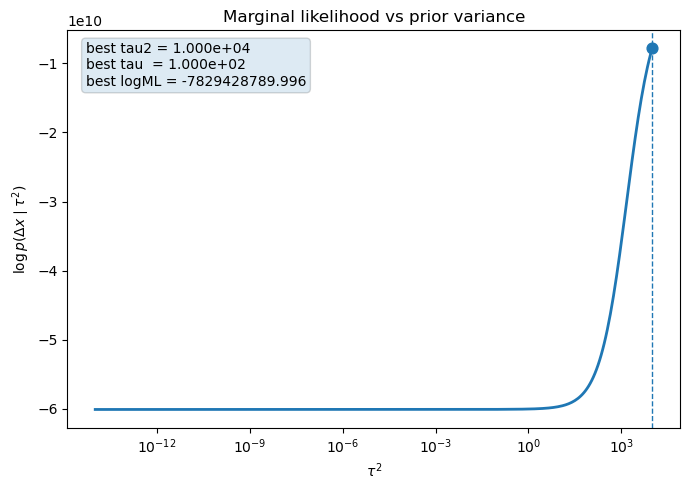

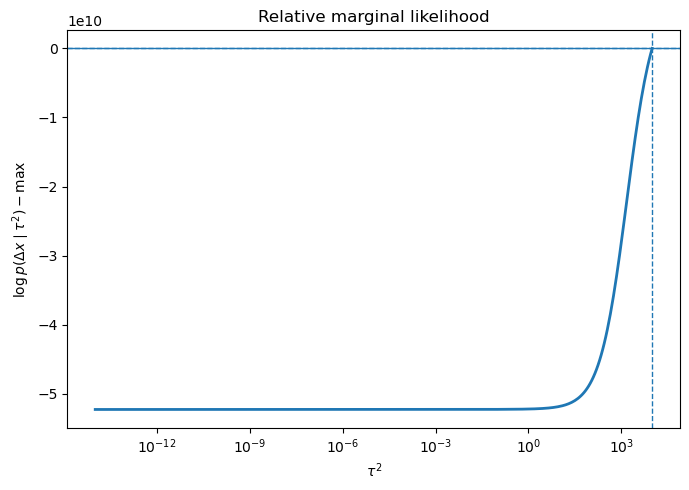

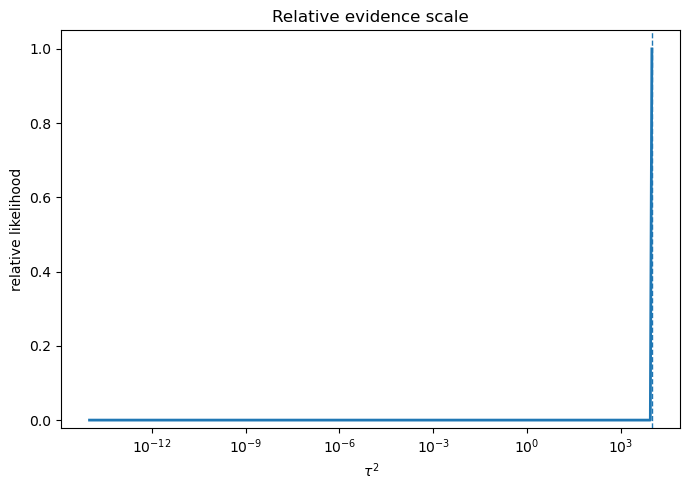

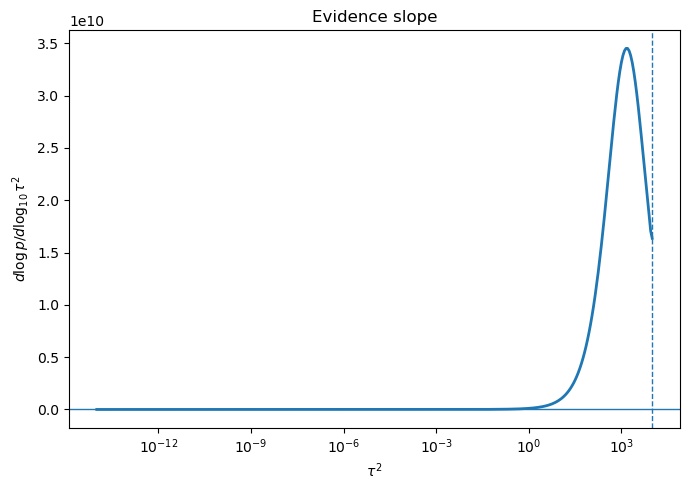

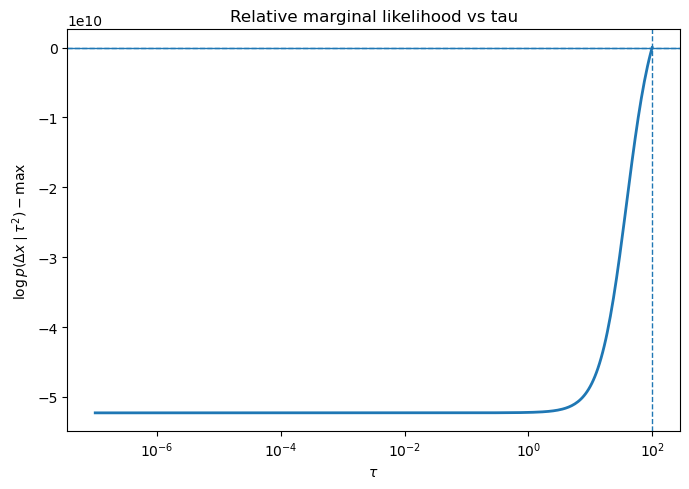

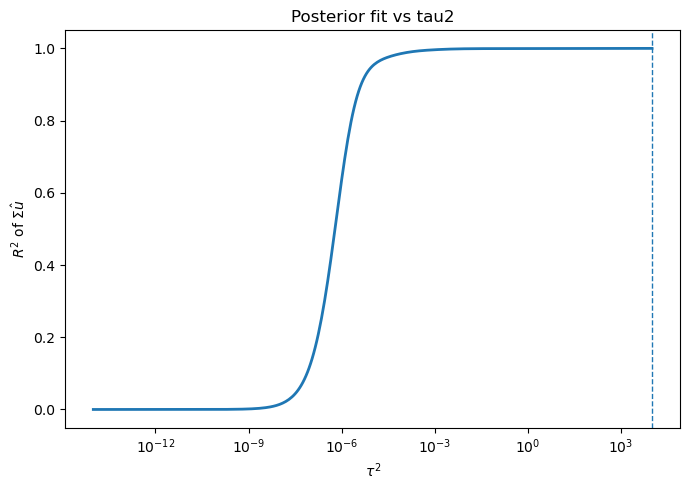

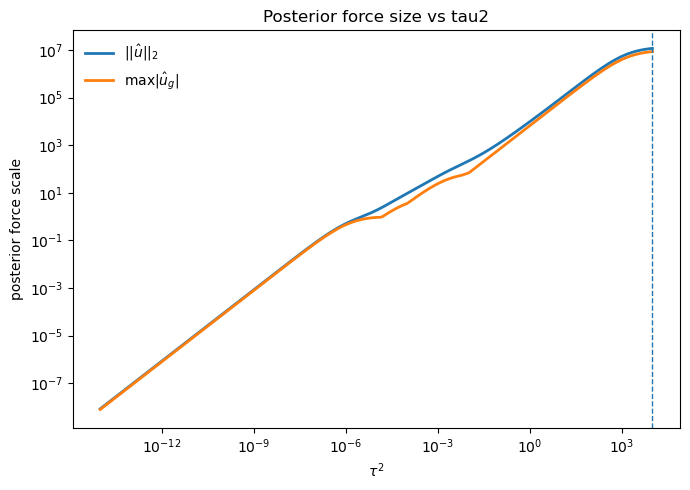

In [4]:
# Compute Sigma / H / delta_x from cells (caches npy under OUTDIR/kras), then sweep tau2.
kras_data = build_selected_matrices_from_cells()
kras_summary = run_tau2_sweep(kras_data, KRAS_DIR)

## Melanoma — GSE233766 naive vs resistant

Contrast `Resistant - Naive` on `GSE233766/Xtot_naive_resistant_melanoma_unbalanced.h5ad`.
Same analytic posterior with the melanoma pipeline's own covariance / DE settings
(`compute_covariance_mel`, `build_H_from_sample_means_mel`, `compute_de_scores_mel`,
`abs_t` ranking, top 2000 with fill). Compute matrices (cached as `.npy` under
`OUTDIR/melanoma`) then run the shared $\tau^2$ sweep.

In [5]:
# --- Melanoma config ---
MEL_DIR = os.path.join(OUTDIR, "melanoma")
os.makedirs(MEL_DIR, exist_ok=True)

sp.H5AD_PATH = os.path.join(SUPPL, "GSE233766", "Xtot_naive_resistant_melanoma_unbalanced.h5ad")
sp.OUTDIR = Path(MEL_DIR)   # the melanoma pipeline functions read the module global OUTDIR

sp.CONDITION_KEY = "Condition"
sp.COND0 = "Naive"
sp.COND1 = "Resistant"

sp.GENES_TO_HIGHLIGHT = ["IGFBP7", "FN1"]

# DE selection
sp.TOP_N_DE = 2000
sp.FDR_ALPHA = 0.05
sp.MIN_ABS_LOG2FC = 0.01
sp.MIN_ABS_DELTA = 0.02
sp.RANK_BY = "abs_t"
sp.FILL_TO_TOP_N = True

# Filtering
sp.DROP_HOUSEKEEPING = True
sp.MIN_CELLS_FRAC = 0.01
sp.MIN_EXPR = 0.01
sp.MIN_MEAN = 0.001
sp.MAX_MEAN = np.inf
sp.MAX_VAR_QUANTILE = 1.0
sp.FILTER_SUBSAMPLE_CELLS = 0
sp.SEED = 0

# DE log2FC pseudocount
sp.LOGFC_PSEUDOCOUNT = 1.0

# Covariance / H
sp.SIGMA_SHRINKAGE = 1e-6
sp.H_SHRINKAGE = 1e-6
sp.H_RIDGE = 1e-6
sp.H_MODE = "naive"

print("[Melanoma] h5ad:", sp.H5AD_PATH)
print("[Melanoma] cache:", sp.OUTDIR)

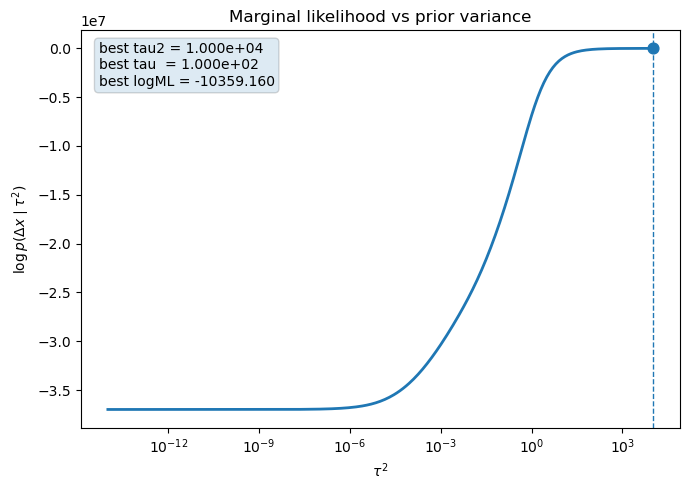

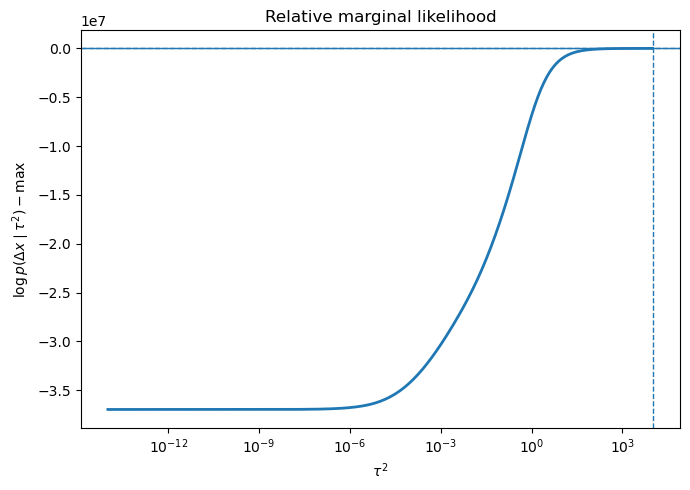

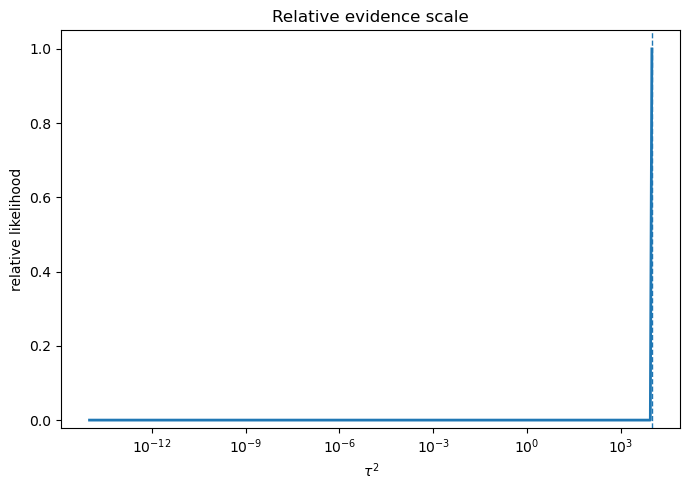

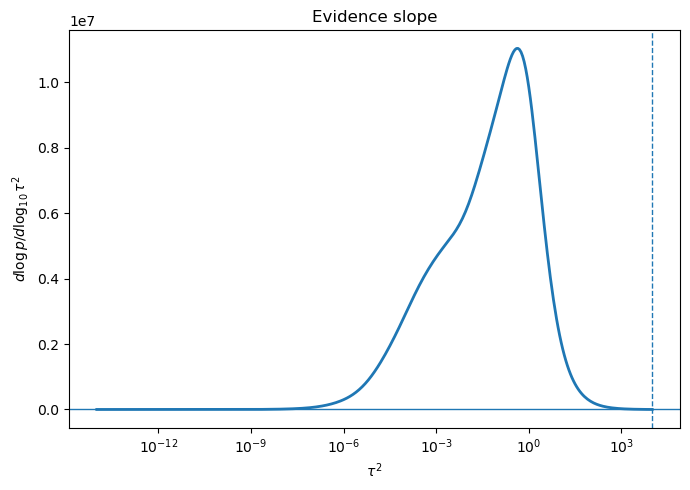

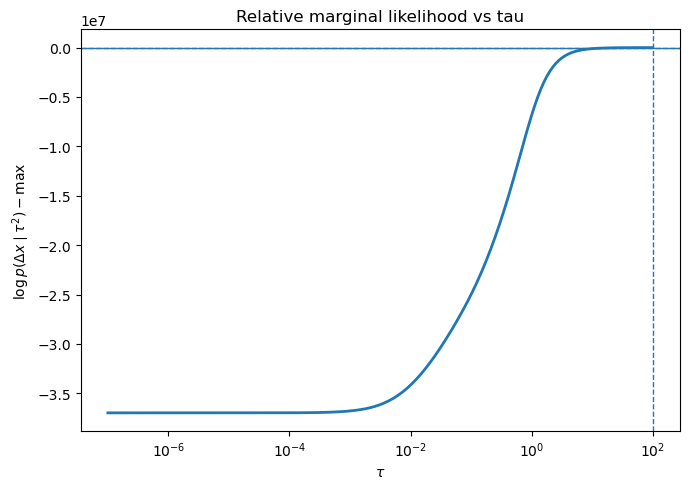

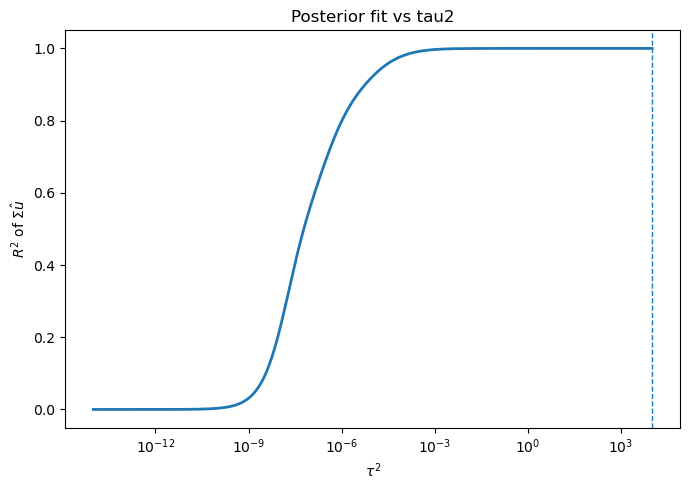

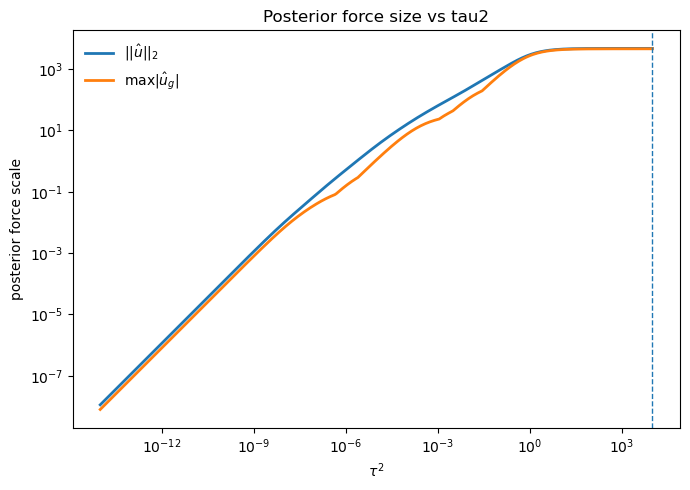

In [6]:
# Compute Sigma / H / delta_x from cells (caches npy under OUTDIR/melanoma), then sweep tau2.
mel_data = build_selected_matrices_from_cells_mel()
mel_summary = run_tau2_sweep(mel_data, MEL_DIR)